# Model Predictive Control for Motion Planning
## From Linear MPC to Nonlinear MPC with Obstacle Avoidance

This notebook provides a complete, from-scratch implementation of **Model Predictive Control (MPC)** — the dominant framework for constrained optimal control in robotics. We build from linear MPC as a QP to nonlinear MPC for mobile robot navigation with obstacle avoidance.

**What you'll learn:**
1. Linear MPC formulation as a Quadratic Program (QP) with the receding horizon principle
2. Stability guarantees via terminal cost and terminal constraints
3. Nonlinear MPC (NMPC) using direct collocation transcription
4. Real-time iteration scheme for fast NMPC
5. Obstacle avoidance as nonlinear constraints
6. Applications: mobile robot navigation and quadrotor trajectory tracking

**Prerequisites:** LQR (Riccati equation), convex optimization (QP), nonlinear optimization (SQP basics).

**References:**
- Rawlings, J.B., Mayne, D.Q. & Diehl, M. *Model Predictive Control: Theory, Computation, and Design*, 2nd ed., Nob Hill Publishing, 2019.
- Borrelli, F., Bemporad, A. & Morari, M. *Predictive Control for Linear and Hybrid Systems*, Cambridge University Press, 2017.
- See also: [LQR notebook](../lqr-control/lqr_control.ipynb), [Convex Optimization notebook](../../maths/optimization/convex-optimization/convex_optimization.ipynb), [SQP notebook](../../maths/optimization/sqp-interior-point/sqp_interior_point.ipynb).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.linalg import solve_discrete_are, block_diag
import time

%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

In [2]:
# =============================================================================
# Global Constants
# =============================================================================

# Simulation parameters
DT = 0.1                # Discrete time step (s)

# Double integrator (linear MPC example)
N_HORIZON_LIN = 20      # MPC horizon for linear system
T_SIM_LIN = 8.0         # Simulation time for linear MPC (s)
U_MAX_LIN = 1.0         # Input bound for double integrator

# Pendulum (NMPC example)
N_HORIZON_NL = 25        # MPC horizon for nonlinear system
T_SIM_NL = 8.0           # Simulation time for NMPC (s)
M_PEND = 1.0             # Pendulum mass (kg)
L_PEND = 1.0             # Pendulum length (m)
B_PEND = 0.1             # Damping coefficient
G_ACCEL = 9.81           # Gravitational acceleration (m/s^2)
U_MAX_PEND = 5.0         # Max torque for pendulum (Nm)

# Mobile robot (unicycle) parameters
V_MAX_UNI = 1.5          # Max linear velocity (m/s)
W_MAX_UNI = 1.5          # Max angular velocity (rad/s)
N_HORIZON_UNI = 20       # Horizon for unicycle MPC
T_SIM_UNI = 25.0         # Simulation time for navigation (s)

# Quadrotor parameters
M_QUAD = 0.5             # Mass (kg)
I_QUAD = 0.01            # Moment of inertia (kg*m^2)
T_MAX_QUAD = 2.0 * M_QUAD * G_ACCEL  # Max total thrust
N_HORIZON_QUAD = 20      # Horizon for quadrotor MPC
T_SIM_QUAD = 12.0        # Simulation time for quadrotor (s)

# Obstacle environments
OBSTACLES_NAV = [
    (3.0, 3.0, 1.0),    # (x, y, radius)
    (5.0, 6.0, 0.8),
    (7.0, 3.5, 1.2),
    (4.5, 8.0, 0.7),
    (8.5, 7.0, 0.9),
]

OBSTACLES_QUAD = [
    (3.0, 2.0, 0.8),
    (6.0, 3.0, 0.6),
    (9.0, 1.5, 0.7),
]

# Numerical tolerance
TOL = 1e-6

# Plot colors
C_BLUE = 'steelblue'
C_RED = 'coral'
C_GREEN = 'seagreen'
C_GOLD = 'goldenrod'
C_PURPLE = 'mediumpurple'

---
## 1. Introduction — Why MPC?

Model Predictive Control sits at the intersection of optimal control theory and real-time computation. Unlike classical controllers, MPC explicitly handles **constraints** on states and inputs while optimizing a performance criterion over a finite horizon.

### Comparison of Control Approaches

| Property | LQR | Trajectory Optimization | MPC |
|---|---|---|---|
| **Dynamics** | Linear | Nonlinear | Nonlinear |
| **Constraints** | Unconstrained | Constrained | Constrained |
| **Horizon** | Infinite | Finite (offline) | Finite (receding) |
| **Solution** | Closed-form (Riccati) | NLP (offline) | NLP (online, each step) |
| **Feedback** | State feedback gain $K$ | Open-loop trajectory | Implicit feedback via re-solving |
| **Computational cost** | Negligible online | High offline, none online | Moderate each step |

### The Receding Horizon Principle

At each time step $k$, MPC:
1. **Measures** the current state $x_k$
2. **Solves** a finite-horizon optimal control problem (OCP) from $x_k$ over $N$ steps
3. **Applies** only the first control action $u_0^*$ to the plant
4. **Shifts** the horizon forward and repeats at step $k+1$

This creates an **implicit feedback law** $u_k = \kappa_{MPC}(x_k)$ — even though each OCP is open-loop, the repeated re-solving provides robustness to disturbances and model errors.

$$\min_{u_0, \ldots, u_{N-1}} \sum_{i=0}^{N-1} \ell(x_i, u_i) + V_f(x_N) \quad \text{s.t. } x_{i+1} = f(x_i, u_i), \; x_i \in \mathcal{X}, \; u_i \in \mathcal{U}, \; x_N \in \mathcal{X}_f$$

---
## 2. Linear MPC as a Quadratic Program

For a discrete-time LTI system $x_{k+1} = Ax_k + Bu_k$, the MPC problem with quadratic costs becomes a **Quadratic Program (QP)**.

### Dense QP Formulation

Given the stage cost $\ell(x,u) = x^\top Q x + u^\top R u$ and terminal cost $V_f(x) = x^\top P_f x$, we can eliminate all state variables using the prediction model:

$$x_i = A^i x_0 + \sum_{j=0}^{i-1} A^{i-1-j} B u_j$$

Define the stacked prediction matrices. Let $\mathbf{X} = [x_1^\top, \ldots, x_N^\top]^\top$ and $\mathbf{U} = [u_0^\top, \ldots, u_{N-1}^\top]^\top$. Then:

$$\mathbf{X} = \mathcal{A} x_0 + \mathcal{B} \mathbf{U}$$

where $\mathcal{A} = [A^\top, (A^2)^\top, \ldots, (A^N)^\top]^\top$ and $\mathcal{B}$ is the lower-triangular block-Toeplitz matrix of impulse responses.

Substituting into the cost gives a QP in $\mathbf{U}$ alone:

$$\min_{\mathbf{U}} \frac{1}{2} \mathbf{U}^\top H \mathbf{U} + \mathbf{U}^\top f$$

where $H = \mathcal{B}^\top \bar{Q} \mathcal{B} + \bar{R}$ and $f = \mathcal{B}^\top \bar{Q} \mathcal{A} x_0$, with $\bar{Q} = \text{blkdiag}(Q, \ldots, Q, P_f)$ and $\bar{R} = \text{blkdiag}(R, \ldots, R)$.

### Terminal Cost from DARE

Setting $P_f$ as the solution to the **Discrete Algebraic Riccati Equation** (DARE) ensures that the terminal cost approximates the infinite-horizon LQR cost-to-go, providing a stability guarantee.

### Implementation: Prediction Matrices and QP Solver

In [3]:
def build_prediction_matrices(A, B, N):
    """Build stacked prediction matrices for the dense QP formulation.

    Args:
        A: System matrix. Shape: (n, n).
        B: Input matrix. Shape: (n, m).
        N: Prediction horizon length.

    Returns:
        cal_A: Stacked state prediction matrix. Shape: (N*n, n).
        cal_B: Stacked input prediction matrix. Shape: (N*n, N*m).
    """
    n, m = B.shape
    cal_A = np.zeros((N * n, n))
    cal_B = np.zeros((N * n, N * m))

    A_pow = np.eye(n)
    for i in range(N):
        A_pow = A_pow @ A
        cal_A[i*n:(i+1)*n, :] = A_pow
        for j in range(i + 1):
            cal_B[i*n:(i+1)*n, j*m:(j+1)*m] = np.linalg.matrix_power(A, i - j) @ B

    return cal_A, cal_B


def solve_linear_mpc_step(A, B, Q, R, Pf, N, x0, u_bounds):
    """Solve one step of linear MPC by forming and solving the dense QP.

    Args:
        A: System matrix. Shape: (n, n).
        B: Input matrix. Shape: (n, m).
        Q: State cost matrix. Shape: (n, n).
        R: Input cost matrix. Shape: (m, m).
        Pf: Terminal cost matrix. Shape: (n, n).
        N: Prediction horizon.
        x0: Current state. Shape: (n,).
        u_bounds: Tuple (u_min, u_max) for each input component.

    Returns:
        u_opt: Optimal first control action. Shape: (m,).
        U_full: Full optimal control sequence. Shape: (N*m,).
        cost: Optimal cost value.
    """
    n, m = B.shape
    cal_A, cal_B = build_prediction_matrices(A, B, N)

    # Build block-diagonal cost matrices
    Q_bar = block_diag(*[Q]*(N-1), Pf)
    R_bar = block_diag(*[R]*N)

    # QP matrices: min 0.5 U^T H U + f^T U
    H = cal_B.T @ Q_bar @ cal_B + R_bar
    H = 0.5 * (H + H.T)  # Ensure symmetry
    f = cal_B.T @ Q_bar @ cal_A @ x0

    # Constant term (doesn't affect optimal U)
    const = x0.T @ cal_A.T @ Q_bar @ cal_A @ x0 + x0.T @ Q @ x0

    # Solve via scipy (SLSQP with box constraints)
    bounds_list = [(u_bounds[0], u_bounds[1])] * (N * m)

    def qp_obj(U):
        return 0.5 * U @ H @ U + f @ U

    def qp_grad(U):
        return H @ U + f

    res = minimize(qp_obj, np.zeros(N * m), jac=qp_grad, bounds=bounds_list, method='SLSQP')
    U_opt = res.x
    u_opt = U_opt[:m]
    cost = res.fun + const

    return u_opt, U_opt, cost


def run_linear_mpc(A, B, Q, R, Pf, N, x0, T_sim, dt, u_bounds):
    """Run receding-horizon linear MPC simulation.

    Args:
        A: System matrix. Shape: (n, n).
        B: Input matrix. Shape: (n, m).
        Q: State cost matrix. Shape: (n, n).
        R: Input cost matrix. Shape: (m, m).
        Pf: Terminal cost matrix. Shape: (n, n).
        N: Prediction horizon.
        x0: Initial state. Shape: (n,).
        T_sim: Total simulation time (s).
        dt: Time step (s).
        u_bounds: Tuple (u_min, u_max).

    Returns:
        xs: State trajectory. Shape: (n_steps+1, n).
        us: Control trajectory. Shape: (n_steps, m).
        costs: Cost-to-go at each step. Shape: (n_steps,).
    """
    n_steps = int(T_sim / dt)
    n = A.shape[0]
    m = B.shape[1]

    xs = np.zeros((n_steps + 1, n))
    us = np.zeros((n_steps, m))
    costs = np.zeros(n_steps)
    xs[0] = x0

    for k in range(n_steps):
        u_opt, _, cost = solve_linear_mpc_step(A, B, Q, R, Pf, N, xs[k], u_bounds)
        us[k] = u_opt
        costs[k] = cost
        xs[k + 1] = A @ xs[k] + B @ u_opt

    return xs, us, costs

print("Linear MPC functions defined.")

Linear MPC functions defined.


In [4]:
# Double integrator: x = [position, velocity], u = acceleration
# Continuous: x_dot = [[0,1],[0,0]] x + [[0],[1]] u
# Discrete (Euler): x_{k+1} = (I + dt*Ac) x_k + dt*Bc u_k

A_di = np.array([[1.0, DT],
                  [0.0, 1.0]])
B_di = np.array([[0.5 * DT**2],
                  [DT]])

Q_di = np.diag([10.0, 1.0])
R_di = np.array([[1.0]])

# Terminal cost from DARE
Pf_di = solve_discrete_are(A_di, B_di, Q_di, R_di)
K_lqr_di = np.linalg.solve(R_di + B_di.T @ Pf_di @ B_di, B_di.T @ Pf_di @ A_di)

print(f"DARE terminal cost Pf:\n{Pf_di}")
print(f"LQR gain K: {K_lqr_di}")

# Initial state: far from origin
x0_di = np.array([5.0, 0.0])

# Run MPC
xs_mpc, us_mpc, costs_mpc = run_linear_mpc(
    A_di, B_di, Q_di, R_di, Pf_di, N_HORIZON_LIN, x0_di, T_SIM_LIN, DT,
    (-U_MAX_LIN, U_MAX_LIN)
)

# Run saturated LQR for comparison
n_steps_lin = int(T_SIM_LIN / DT)
xs_lqr = np.zeros((n_steps_lin + 1, 2))
us_lqr = np.zeros((n_steps_lin, 1))
xs_lqr[0] = x0_di

for k in range(n_steps_lin):
    u_lqr = -K_lqr_di @ xs_lqr[k]
    u_lqr_sat = np.clip(u_lqr, -U_MAX_LIN, U_MAX_LIN)
    us_lqr[k] = u_lqr_sat
    xs_lqr[k + 1] = A_di @ xs_lqr[k] + B_di @ u_lqr_sat

# Verification
final_pos_mpc = np.abs(xs_mpc[-1, 0])
constraint_ok = np.all(np.abs(us_mpc) <= U_MAX_LIN + TOL)

status1 = "PASS" if final_pos_mpc < 0.1 else "FAIL"
print(f"MPC reaches origin (|x_final| < 0.1): {final_pos_mpc:.4f} [{status1}]")

status2 = "PASS" if constraint_ok else "FAIL"
print(f"MPC satisfies input constraints: {np.max(np.abs(us_mpc)):.4f} <= {U_MAX_LIN} [{status2}]")

DARE terminal cost Pf:
[[90.77561471 31.6622804 ]
 [31.6622804  27.65851564]]
LQR gain K: [[2.76234997 2.50754016]]
MPC reaches origin (|x_final| < 0.1): 0.0027 [PASS]
MPC satisfies input constraints: 1.0000 <= 1.0 [PASS]


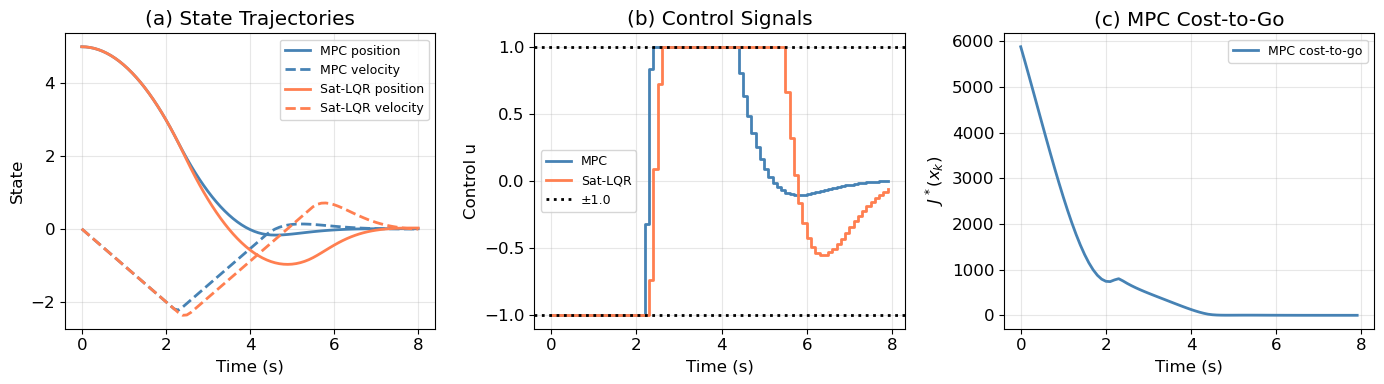

In [5]:
# Visualization: 3-panel comparison
t_lin = np.arange(n_steps_lin + 1) * DT
t_u_lin = np.arange(n_steps_lin) * DT

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) State trajectories
axes[0].plot(t_lin, xs_mpc[:, 0], color=C_BLUE, label='MPC position')
axes[0].plot(t_lin, xs_mpc[:, 1], color=C_BLUE, ls='--', label='MPC velocity')
axes[0].plot(t_lin, xs_lqr[:, 0], color=C_RED, label='Sat-LQR position')
axes[0].plot(t_lin, xs_lqr[:, 1], color=C_RED, ls='--', label='Sat-LQR velocity')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('State')
axes[0].set_title('(a) State Trajectories')
axes[0].legend(fontsize=9)

# (b) Control signals
axes[1].step(t_u_lin, us_mpc[:, 0], color=C_BLUE, where='post', label='MPC')
axes[1].step(t_u_lin, us_lqr[:, 0], color=C_RED, where='post', label='Sat-LQR')
axes[1].axhline(U_MAX_LIN, color='k', ls=':', label=f'±{U_MAX_LIN}')
axes[1].axhline(-U_MAX_LIN, color='k', ls=':')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Control u')
axes[1].set_title('(b) Control Signals')
axes[1].legend(fontsize=9)

# (c) Cost-to-go
axes[2].plot(t_u_lin, costs_mpc, color=C_BLUE, label='MPC cost-to-go')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('$J^*(x_k)$')
axes[2].set_title('(c) MPC Cost-to-Go')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 3. Stability of Linear MPC

### Lyapunov Stability via Terminal Ingredients

The key theoretical result: if we choose the terminal cost $P_f$ and terminal set $\mathcal{X}_f$ such that:

1. $P_f$ satisfies the DARE: $P_f = A_{cl}^\top P_f A_{cl} + Q + K^\top R K$ (where $A_{cl} = A - BK$)
2. $\mathcal{X}_f$ is **positively invariant** under $u = -Kx$: if $x \in \mathcal{X}_f$, then $A_{cl}x \in \mathcal{X}_f$
3. $\mathcal{X}_f \subseteq \{x : |Kx| \leq u_{max}\}$ (constraints are satisfied in terminal set)

Then the optimal cost $J^*(x_k)$ is a **Lyapunov function**, and the closed-loop system is asymptotically stable.

**Intuition:** The terminal set is a "safe haven" — once the predicted trajectory enters it, the LQR controller can stabilize the system without violating constraints. The terminal cost accurately captures the remaining cost-to-go.

### Computing the Maximal Positively Invariant Set

For a 2D system, we iteratively tighten constraints by propagating them backward through the closed-loop dynamics $A_{cl}$ until convergence.

In [6]:
def compute_terminal_set_2d(A_cl, K_lqr, u_max, n_iter=50):
    """Compute maximal positively invariant set for a 2D system via constraint propagation.

    The terminal set is defined by {x : F x <= g} where we iteratively add
    constraints from F @ A_cl^k x <= g for k = 0, 1, ...

    For simplicity, we use input constraints |K x| <= u_max and approximate
    the invariant set as the level set of x^T P x <= alpha.

    Args:
        A_cl: Closed-loop system matrix. Shape: (2, 2).
        K_lqr: LQR gain. Shape: (1, 2).
        u_max: Input bound scalar.
        n_iter: Max iterations for constraint propagation.

    Returns:
        alpha: Level set value for ellipsoidal approximation.
        P_lyap: Lyapunov matrix for the ellipsoid x^T P x <= alpha.
    """
    # Solve discrete Lyapunov equation for A_cl: P = A_cl^T P A_cl + I
    # This gives an ellipsoidal invariant set
    from scipy.linalg import solve_discrete_lyapunov
    P_lyap = solve_discrete_lyapunov(A_cl.T, np.eye(2))

    # Find largest alpha such that x^T P x <= alpha implies |K x| <= u_max
    # |K x|^2 <= u_max^2 for all x with x^T P x <= alpha
    # Maximize K x subject to x^T P x = alpha => max = alpha * K P^{-1} K^T
    # So we need alpha * K P^{-1} K^T <= u_max^2
    P_inv = np.linalg.inv(P_lyap)
    kpk = K_lqr @ P_inv @ K_lqr.T
    alpha = u_max**2 / kpk[0, 0]

    return alpha, P_lyap

# Compute terminal set for double integrator
A_cl_di = A_di - B_di @ K_lqr_di
alpha_di, P_lyap_di = compute_terminal_set_2d(A_cl_di, K_lqr_di, U_MAX_LIN)
print(f"Terminal set: x^T P x <= {alpha_di:.4f}")
print(f"Lyapunov matrix P:\n{P_lyap_di}")

Terminal set: x^T P x <= 0.4394
Lyapunov matrix P:
[[12.52418805  1.62259317]
 [ 1.62259317  2.98306984]]


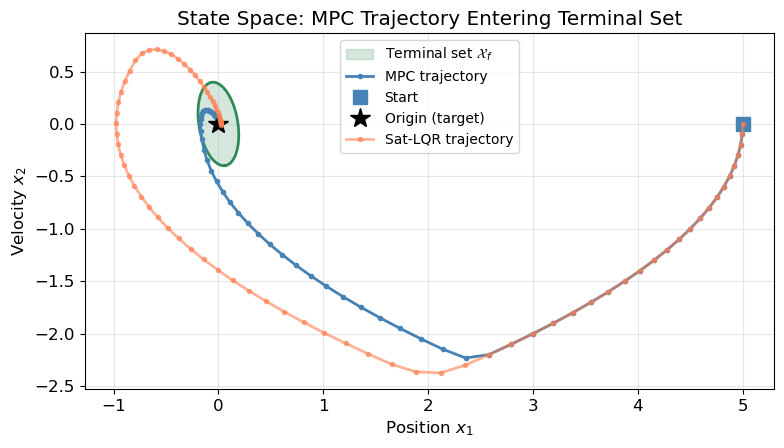

In [7]:
# Visualization: terminal set and MPC trajectory in state space
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Draw terminal ellipsoid
theta_ell = np.linspace(0, 2 * np.pi, 200)
# Eigendecomposition for ellipse
eigvals, eigvecs = np.linalg.eigh(P_lyap_di)
ell_pts = np.column_stack([np.cos(theta_ell), np.sin(theta_ell)])
ell_pts = ell_pts @ np.diag(np.sqrt(alpha_di / eigvals)) @ eigvecs.T
ax.fill(ell_pts[:, 0], ell_pts[:, 1], alpha=0.2, color=C_GREEN, label='Terminal set $\\mathcal{X}_f$')
ax.plot(ell_pts[:, 0], ell_pts[:, 1], color=C_GREEN, lw=2)

# MPC trajectory
ax.plot(xs_mpc[:, 0], xs_mpc[:, 1], 'o-', color=C_BLUE, markersize=3, label='MPC trajectory')
ax.plot(xs_mpc[0, 0], xs_mpc[0, 1], 's', color=C_BLUE, markersize=10, label='Start')
ax.plot(0, 0, '*', color='k', markersize=15, label='Origin (target)')

# Sat-LQR trajectory
ax.plot(xs_lqr[:, 0], xs_lqr[:, 1], 'o-', color=C_RED, markersize=3, alpha=0.6, label='Sat-LQR trajectory')

ax.set_xlabel('Position $x_1$')
ax.set_ylabel('Velocity $x_2$')
ax.set_title('State Space: MPC Trajectory Entering Terminal Set')
ax.legend(fontsize=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 4. Nonlinear MPC (NMPC)

When the dynamics are nonlinear, $x_{k+1} = f(x_k, u_k)$, the MPC problem becomes a **Nonlinear Program (NLP)**. We can no longer eliminate states analytically — instead we keep both states and controls as decision variables and enforce dynamics as equality constraints.

### Direct Transcription Approach

Pack all decision variables into a single vector:
$$z = [x_0, u_0, x_1, u_1, \ldots, x_{N-1}, u_{N-1}, x_N]$$

The NLP becomes:
$$\min_z \sum_{i=0}^{N-1} \ell(x_i, u_i) + V_f(x_N)$$
$$\text{s.t. } x_{i+1} = f(x_i, u_i), \quad x_0 = \bar{x}, \quad u_i \in [u_{min}, u_{max}]$$

We solve this with `scipy.optimize.minimize` (SLSQP), which handles both equality constraints (dynamics) and box constraints (input bounds).

### Warm-Starting

A critical trick for real-time feasibility: at time $k+1$, initialize the NLP with the **shifted** solution from time $k$:
- States: $[x_1^*, x_2^*, \ldots, x_N^*, f(x_N^*, 0)]$
- Controls: $[u_1^*, u_2^*, \ldots, u_{N-1}^*, 0]$

This provides a nearly feasible initial guess, dramatically reducing solve time.

### Implementation: Generic NMPC Solver

In [8]:
def rk4_step(f, x, u, dt):
    """Single Runge-Kutta 4 integration step.

    Args:
        f: Continuous dynamics function f(x, u) -> x_dot.
        x: Current state. Shape: (n,).
        u: Control input. Shape: (m,).
        dt: Time step.

    Returns:
        x_next: Next state. Shape: (n,).
    """
    k1 = f(x, u)
    k2 = f(x + 0.5 * dt * k1, u)
    k3 = f(x + 0.5 * dt * k2, u)
    k4 = f(x + dt * k3, u)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def pack_z(xs, us, n_x, n_u, N):
    """Pack state and control trajectories into a flat decision vector.

    Args:
        xs: State trajectory. Shape: (N+1, n_x).
        us: Control trajectory. Shape: (N, n_u).
        n_x: State dimension.
        n_u: Control dimension.
        N: Horizon length.

    Returns:
        z: Flat decision vector. Shape: ((N+1)*n_x + N*n_u,).
    """
    z = np.zeros((N + 1) * n_x + N * n_u)
    for i in range(N):
        idx = i * (n_x + n_u)
        z[idx:idx + n_x] = xs[i]
        z[idx + n_x:idx + n_x + n_u] = us[i]
    z[N * (n_x + n_u):] = xs[N]
    return z


def unpack_z(z, n_x, n_u, N):
    """Unpack flat decision vector into state and control trajectories.

    Args:
        z: Flat decision vector. Shape: ((N+1)*n_x + N*n_u,).
        n_x: State dimension.
        n_u: Control dimension.
        N: Horizon length.

    Returns:
        xs: State trajectory. Shape: (N+1, n_x).
        us: Control trajectory. Shape: (N, n_u).
    """
    xs = np.zeros((N + 1, n_x))
    us = np.zeros((N, n_u))
    for i in range(N):
        idx = i * (n_x + n_u)
        xs[i] = z[idx:idx + n_x]
        us[i] = z[idx + n_x:idx + n_x + n_u]
    xs[N] = z[N * (n_x + n_u):]
    return xs, us


def nmpc_solve_step(dynamics_ct, x0, x_ref, Q, R, Qf, N, dt, u_bounds, x_warm, u_warm):
    """Solve one NMPC step via direct transcription and SLSQP.

    Args:
        dynamics_ct: Continuous-time dynamics f(x, u) -> x_dot.
        x0: Current state. Shape: (n_x,).
        x_ref: Reference state. Shape: (n_x,).
        Q: State cost matrix. Shape: (n_x, n_x).
        R: Input cost matrix. Shape: (n_u, n_u).
        Qf: Terminal cost matrix. Shape: (n_x, n_x).
        N: Horizon length.
        dt: Time step.
        u_bounds: List of (u_min, u_max) for each control.
        x_warm: Warm-start states. Shape: (N+1, n_x).
        u_warm: Warm-start controls. Shape: (N, n_u).

    Returns:
        xs_opt: Optimal state trajectory. Shape: (N+1, n_x).
        us_opt: Optimal control trajectory. Shape: (N, n_u).
        solve_time: Time to solve (s).
    """
    n_x = len(x0)
    n_u = R.shape[0]

    def objective(z):
        xs, us = unpack_z(z, n_x, n_u, N)
        cost = 0.0
        for i in range(N):
            dx = xs[i] - x_ref
            cost += dx @ Q @ dx + us[i] @ R @ us[i]
        dx_N = xs[N] - x_ref
        cost += dx_N @ Qf @ dx_N
        return cost

    def dynamics_constraints(z):
        xs, us = unpack_z(z, n_x, n_u, N)
        ceq = []
        # Initial condition
        ceq.extend(xs[0] - x0)
        # Dynamics
        for i in range(N):
            x_next = rk4_step(dynamics_ct, xs[i], us[i], dt)
            ceq.extend(xs[i + 1] - x_next)
        return np.array(ceq)

    # Build bounds: no bounds on states, box bounds on controls
    bounds_list = []
    for i in range(N):
        bounds_list.extend([(None, None)] * n_x)  # states
        bounds_list.extend(u_bounds)  # controls
    bounds_list.extend([(None, None)] * n_x)  # terminal state

    z0 = pack_z(x_warm, u_warm, n_x, n_u, N)

    t_start = time.time()
    res = minimize(
        objective, z0, method='SLSQP',
        constraints={'type': 'eq', 'fun': dynamics_constraints},
        bounds=bounds_list,
        options={'maxiter': 200, 'ftol': 1e-8}
    )
    solve_time = time.time() - t_start

    xs_opt, us_opt = unpack_z(res.x, n_x, n_u, N)
    return xs_opt, us_opt, solve_time


def run_nmpc(dynamics_ct, x0, x_ref, Q, R, Qf, N, T_sim, dt, u_bounds, n_u):
    """Run full receding-horizon NMPC with warm-starting.

    Args:
        dynamics_ct: Continuous-time dynamics f(x, u) -> x_dot.
        x0: Initial state. Shape: (n_x,).
        x_ref: Reference state. Shape: (n_x,).
        Q: State cost matrix. Shape: (n_x, n_x).
        R: Input cost matrix. Shape: (n_u, n_u).
        Qf: Terminal cost matrix. Shape: (n_x, n_x).
        N: Horizon length.
        T_sim: Total simulation time (s).
        dt: Time step (s).
        u_bounds: List of (u_min, u_max) per control dimension.
        n_u: Control dimension.

    Returns:
        xs: State trajectory. Shape: (n_steps+1, n_x).
        us: Control trajectory. Shape: (n_steps, n_u).
        solve_times: Solve time per step. Shape: (n_steps,).
        predictions: List of predicted trajectories at select steps.
    """
    n_steps = int(T_sim / dt)
    n_x = len(x0)

    xs = np.zeros((n_steps + 1, n_x))
    us = np.zeros((n_steps, n_u))
    solve_times = np.zeros(n_steps)
    xs[0] = x0

    # Initial guess: linear interpolation for states, zeros for controls
    x_warm = np.linspace(x0, x_ref, N + 1)
    u_warm = np.zeros((N, n_u))

    predictions = {}
    save_steps = [0, n_steps // 4, n_steps // 2, 3 * n_steps // 4]

    for k in range(n_steps):
        xs_pred, us_pred, t_solve = nmpc_solve_step(
            dynamics_ct, xs[k], x_ref, Q, R, Qf, N, dt, u_bounds, x_warm, u_warm
        )
        solve_times[k] = t_solve
        us[k] = us_pred[0]
        xs[k + 1] = rk4_step(dynamics_ct, xs[k], us[k], dt)

        if k in save_steps:
            predictions[k] = xs_pred.copy()

        # Warm-start: shift
        x_warm[:-1] = xs_pred[1:]
        x_warm[-1] = xs_pred[-1]  # Repeat last
        u_warm[:-1] = us_pred[1:]
        u_warm[-1] = us_pred[-1] if N > 1 else np.zeros(n_u)

    return xs, us, solve_times, predictions

print("NMPC functions defined.")

NMPC functions defined.


In [9]:
# Pendulum swing-up: state = [theta, theta_dot], control = [torque]
# Goal: swing from hanging down (theta=0) to upright (theta=pi)

def pendulum_dynamics_ct(x, u):
    """Continuous-time pendulum dynamics.

    Args:
        x: State [theta, theta_dot]. Shape: (2,).
        u: Torque. Shape: (1,).

    Returns:
        x_dot: State derivative. Shape: (2,).
    """
    theta, theta_dot = x
    tau = u[0]
    theta_ddot = (-B_PEND * theta_dot + M_PEND * G_ACCEL * L_PEND * np.sin(theta) + tau) / (M_PEND * L_PEND**2)
    return np.array([theta_dot, theta_ddot])

# Reference: upright position
x_ref_pend = np.array([np.pi, 0.0])
x0_pend = np.array([0.0, 0.0])  # hanging down

Q_pend = np.diag([10.0, 1.0])
R_pend = np.diag([0.1])
Qf_pend = np.diag([100.0, 10.0])

u_bounds_pend = [(-U_MAX_PEND, U_MAX_PEND)]

print("Running pendulum NMPC swing-up (this may take ~30s)...")
xs_pend, us_pend, times_pend, preds_pend = run_nmpc(
    pendulum_dynamics_ct, x0_pend, x_ref_pend, Q_pend, R_pend, Qf_pend,
    N_HORIZON_NL, T_SIM_NL, DT, u_bounds_pend, n_u=1
)

# Verification
final_err = np.abs(xs_pend[-1, 0] - np.pi)
status = "PASS" if final_err < 0.3 else "FAIL"
print(f"Pendulum final angle error from upright: {final_err:.4f} rad [{status}]")
print(f"Mean solve time: {np.mean(times_pend)*1000:.1f} ms")

Running pendulum NMPC swing-up (this may take ~30s)...
Pendulum final angle error from upright: 0.0000 rad [PASS]
Mean solve time: 473.0 ms


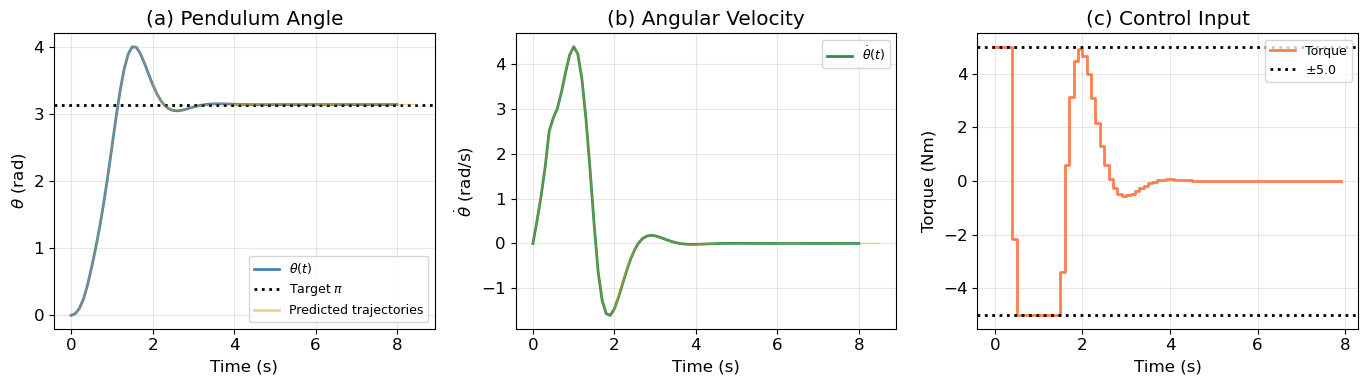

In [10]:
# Visualization: pendulum NMPC
n_steps_pend = int(T_SIM_NL / DT)
t_pend = np.arange(n_steps_pend + 1) * DT
t_u_pend = np.arange(n_steps_pend) * DT

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Angle trajectory with prediction fans
axes[0].plot(t_pend, xs_pend[:, 0], color=C_BLUE, label='$\\theta(t)$')
axes[0].axhline(np.pi, color='k', ls=':', label='Target $\\pi$')
for step_k, pred in preds_pend.items():
    t_pred = (step_k + np.arange(len(pred))) * DT
    axes[0].plot(t_pred, pred[:, 0], color=C_GOLD, alpha=0.4, lw=1)
axes[0].plot([], [], color=C_GOLD, alpha=0.5, label='Predicted trajectories')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('$\\theta$ (rad)')
axes[0].set_title('(a) Pendulum Angle')
axes[0].legend(fontsize=9)

# (b) Angular velocity
axes[1].plot(t_pend, xs_pend[:, 1], color=C_GREEN, label='$\\dot{\\theta}(t)$')
for step_k, pred in preds_pend.items():
    t_pred = (step_k + np.arange(len(pred))) * DT
    axes[1].plot(t_pred, pred[:, 1], color=C_GOLD, alpha=0.4, lw=1)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('$\\dot{\\theta}$ (rad/s)')
axes[1].set_title('(b) Angular Velocity')
axes[1].legend(fontsize=9)

# (c) Control signal
axes[2].step(t_u_pend, us_pend[:, 0], color=C_RED, where='post', label='Torque')
axes[2].axhline(U_MAX_PEND, color='k', ls=':', label=f'$\\pm${U_MAX_PEND}')
axes[2].axhline(-U_MAX_PEND, color='k', ls=':')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Torque (Nm)')
axes[2].set_title('(c) Control Input')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Real-Time Iteration (RTI) Scheme

### The Computational Challenge

Full NMPC requires solving a complete NLP at every time step. For fast systems, this can be prohibitively expensive. The **Real-Time Iteration (RTI)** scheme addresses this by performing only **one SQP iteration** per time step.

### Key Insight

Instead of solving the NLP to convergence, RTI:
1. **Linearizes** dynamics and objective around the current iterate (shifted previous solution)
2. **Solves one QP** (the SQP subproblem)
3. **Applies** the first control from this approximate solution

Under mild assumptions (contractivity of the SQP map), the iterates **track** the optimal solution as the system evolves. The approximation error decreases geometrically and remains bounded.

### When RTI Works Well
- The system evolves slowly relative to the sampling rate
- The warm-start from the shifted solution is close to optimal
- The NLP landscape is "well-behaved" (no sharp local minima)

In [11]:
def rti_nmpc_step(dynamics_ct, x0, x_ref, Q, R, Qf, N, dt, u_bounds, x_warm, u_warm):
    """Perform a single RTI (one SQP iteration) for NMPC.

    Linearize around the warm-start, form a QP, solve it once.

    Args:
        dynamics_ct: Continuous-time dynamics.
        x0: Current state. Shape: (n_x,).
        x_ref: Reference state. Shape: (n_x,).
        Q: State cost. Shape: (n_x, n_x).
        R: Input cost. Shape: (n_u, n_u).
        Qf: Terminal cost. Shape: (n_x, n_x).
        N: Horizon.
        dt: Time step.
        u_bounds: List of (u_min, u_max) per control.
        x_warm: Warm-start states. Shape: (N+1, n_x).
        u_warm: Warm-start controls. Shape: (N, n_u).

    Returns:
        xs_opt: Updated state trajectory. Shape: (N+1, n_x).
        us_opt: Updated control trajectory. Shape: (N, n_u).
        solve_time: Time to solve (s).
    """
    n_x = len(x0)
    n_u = R.shape[0]

    # Use SLSQP with maxiter=1 to approximate one SQP iteration
    def objective(z):
        xs, us = unpack_z(z, n_x, n_u, N)
        cost = 0.0
        for i in range(N):
            dx = xs[i] - x_ref
            cost += dx @ Q @ dx + us[i] @ R @ us[i]
        dx_N = xs[N] - x_ref
        cost += dx_N @ Qf @ dx_N
        return cost

    def dynamics_constraints(z):
        xs, us = unpack_z(z, n_x, n_u, N)
        ceq = []
        ceq.extend(xs[0] - x0)
        for i in range(N):
            x_next = rk4_step(dynamics_ct, xs[i], us[i], dt)
            ceq.extend(xs[i + 1] - x_next)
        return np.array(ceq)

    bounds_list = []
    for i in range(N):
        bounds_list.extend([(None, None)] * n_x)
        bounds_list.extend(u_bounds)
    bounds_list.extend([(None, None)] * n_x)

    z0 = pack_z(x_warm, u_warm, n_x, n_u, N)

    t_start = time.time()
    # RTI: only 1-2 iterations instead of full convergence
    res = minimize(
        objective, z0, method='SLSQP',
        constraints={'type': 'eq', 'fun': dynamics_constraints},
        bounds=bounds_list,
        options={'maxiter': 3, 'ftol': 1e-6}
    )
    solve_time = time.time() - t_start

    xs_opt, us_opt = unpack_z(res.x, n_x, n_u, N)
    return xs_opt, us_opt, solve_time


def run_rti_nmpc(dynamics_ct, x0, x_ref, Q, R, Qf, N, T_sim, dt, u_bounds, n_u):
    """Run RTI-NMPC simulation (limited SQP iterations per step).

    Args:
        dynamics_ct: Continuous-time dynamics.
        x0: Initial state. Shape: (n_x,).
        x_ref: Reference state. Shape: (n_x,).
        Q, R, Qf: Cost matrices.
        N: Horizon length.
        T_sim: Simulation time (s).
        dt: Time step (s).
        u_bounds: Control bounds.
        n_u: Control dimension.

    Returns:
        xs: State trajectory. Shape: (n_steps+1, n_x).
        us: Control trajectory. Shape: (n_steps, n_u).
        solve_times: Solve time per step. Shape: (n_steps,).
    """
    n_steps = int(T_sim / dt)
    n_x = len(x0)

    xs = np.zeros((n_steps + 1, n_x))
    us = np.zeros((n_steps, n_u))
    solve_times = np.zeros(n_steps)
    xs[0] = x0

    x_warm = np.linspace(x0, x_ref, N + 1)
    u_warm = np.zeros((N, n_u))

    for k in range(n_steps):
        xs_pred, us_pred, t_solve = rti_nmpc_step(
            dynamics_ct, xs[k], x_ref, Q, R, Qf, N, dt, u_bounds, x_warm, u_warm
        )
        solve_times[k] = t_solve
        us[k] = us_pred[0]
        xs[k + 1] = rk4_step(dynamics_ct, xs[k], us[k], dt)

        # Warm-start: shift
        x_warm[:-1] = xs_pred[1:]
        x_warm[-1] = xs_pred[-1]
        u_warm[:-1] = us_pred[1:]
        u_warm[-1] = us_pred[-1] if N > 1 else np.zeros(n_u)

    return xs, us, solve_times

# Run RTI on pendulum
print("Running RTI-NMPC for pendulum...")
xs_rti, us_rti, times_rti = run_rti_nmpc(
    pendulum_dynamics_ct, x0_pend, x_ref_pend, Q_pend, R_pend, Qf_pend,
    N_HORIZON_NL, T_SIM_NL, DT, u_bounds_pend, n_u=1
)

final_err_rti = np.abs(xs_rti[-1, 0] - np.pi)
status = "PASS" if final_err_rti < 0.5 else "FAIL"
print(f"RTI final angle error: {final_err_rti:.4f} rad [{status}]")
print(f"RTI mean solve time: {np.mean(times_rti)*1000:.1f} ms vs Full NMPC: {np.mean(times_pend)*1000:.1f} ms")
print(f"Speedup: {np.mean(times_pend)/np.mean(times_rti):.1f}x")

Running RTI-NMPC for pendulum...
RTI final angle error: 0.0000 rad [PASS]
RTI mean solve time: 192.6 ms vs Full NMPC: 473.0 ms
Speedup: 2.5x


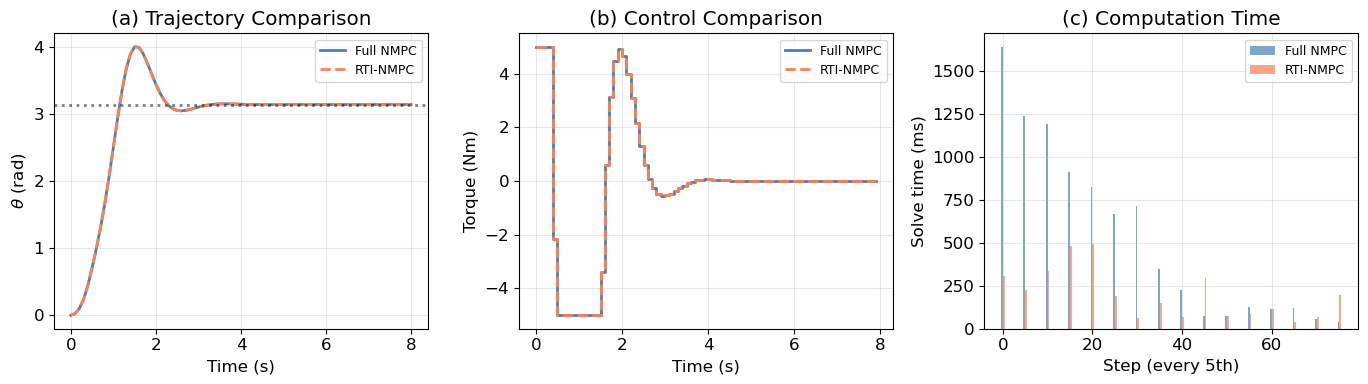

In [12]:
# Visualization: Full NMPC vs RTI comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

t_pend_full = np.arange(int(T_SIM_NL / DT) + 1) * DT

# (a) Trajectories
axes[0].plot(t_pend_full, xs_pend[:, 0], color=C_BLUE, label='Full NMPC')
axes[0].plot(t_pend_full, xs_rti[:, 0], color=C_RED, ls='--', label='RTI-NMPC')
axes[0].axhline(np.pi, color='k', ls=':', alpha=0.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('$\\theta$ (rad)')
axes[0].set_title('(a) Trajectory Comparison')
axes[0].legend(fontsize=9)

# (b) Control comparison
t_u_full = np.arange(int(T_SIM_NL / DT)) * DT
axes[1].step(t_u_full, us_pend[:, 0], color=C_BLUE, where='post', label='Full NMPC')
axes[1].step(t_u_full, us_rti[:, 0], color=C_RED, where='post', ls='--', label='RTI-NMPC')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Torque (Nm)')
axes[1].set_title('(b) Control Comparison')
axes[1].legend(fontsize=9)

# (c) Computation time per step
step_indices = np.arange(len(times_pend))
width = 0.4
axes[2].bar(step_indices[::5] - width/2, times_pend[::5]*1000, width, color=C_BLUE, alpha=0.7, label='Full NMPC')
axes[2].bar(step_indices[::5] + width/2, times_rti[::5]*1000, width, color=C_RED, alpha=0.7, label='RTI-NMPC')
axes[2].set_xlabel('Step (every 5th)')
axes[2].set_ylabel('Solve time (ms)')
axes[2].set_title('(c) Computation Time')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. Obstacle Avoidance Constraints

### Circular Obstacles as Nonlinear Inequality Constraints

For circular obstacles centered at $p_{obs}^j$ with radius $r_j$ (plus a safety margin $r_{robot}$), collision avoidance requires:

$$\|p_k - p_{obs}^j\|^2 \geq (r_j + r_{robot})^2 \quad \forall k = 0, \ldots, N, \; \forall j$$

In the NLP, these become **nonlinear inequality constraints**. Since we need $g(z) \geq 0$ for scipy's SLSQP, we write:

$$g_{k,j}(z) = \|p_k - p_{obs}^j\|^2 - (r_j + r_{robot})^2 \geq 0$$

### Non-convexity Warning

Obstacle avoidance constraints make the NLP **non-convex**. The optimizer may find different local minima depending on the initial guess — for example, going left vs. right around an obstacle. Good warm-starting is crucial to guide the solver toward the desired homotopy class.

In [13]:
def obstacle_constraints(z, obstacles, N, n_x, n_u, pos_indices, r_robot=0.2):
    """Compute obstacle avoidance constraint values for all time steps and obstacles.

    Returns g >= 0 where g[k,j] = ||p_k - p_obs_j||^2 - (r_j + r_robot)^2.

    Args:
        z: Decision vector.
        obstacles: List of (ox, oy, r) tuples.
        N: Horizon length.
        n_x: State dimension.
        n_u: Control dimension.
        pos_indices: Tuple (ix, iy) indices of position in state vector.
        r_robot: Robot radius for safety margin.

    Returns:
        g: Constraint vector (should be >= 0). Shape: ((N+1)*n_obs,).
    """
    xs, _ = unpack_z(z, n_x, n_u, N)
    ix, iy = pos_indices
    g = []
    for i in range(N + 1):
        px, py = xs[i, ix], xs[i, iy]
        for ox, oy, r_obs in obstacles:
            dist_sq = (px - ox)**2 + (py - oy)**2
            g.append(dist_sq - (r_obs + r_robot)**2)
    return np.array(g)


def nmpc_with_obstacles(dynamics_ct, x0, x_ref, Q, R, Qf, N, dt,
                         u_bounds, obstacles, pos_indices, n_u,
                         x_warm, u_warm, r_robot=0.2, maxiter=200):
    """Solve one NMPC step with obstacle avoidance constraints.

    Args:
        dynamics_ct: Continuous-time dynamics.
        x0: Current state. Shape: (n_x,).
        x_ref: Reference state. Shape: (n_x,).
        Q, R, Qf: Cost matrices.
        N: Horizon length.
        dt: Time step.
        u_bounds: Control bounds.
        obstacles: List of (ox, oy, r).
        pos_indices: (ix, iy) position indices in state.
        n_u: Control dimension.
        x_warm, u_warm: Warm-start trajectories.
        r_robot: Robot radius.
        maxiter: Max optimizer iterations.

    Returns:
        xs_opt: Optimal states. Shape: (N+1, n_x).
        us_opt: Optimal controls. Shape: (N, n_u).
        solve_time: Solve time (s).
    """
    n_x = len(x0)

    def objective(z):
        xs, us = unpack_z(z, n_x, n_u, N)
        cost = 0.0
        for i in range(N):
            dx = xs[i] - x_ref
            cost += dx @ Q @ dx + us[i] @ R @ us[i]
        dx_N = xs[N] - x_ref
        cost += dx_N @ Qf @ dx_N
        return cost

    def dyn_eq(z):
        xs, us = unpack_z(z, n_x, n_u, N)
        ceq = list(xs[0] - x0)
        for i in range(N):
            x_next = rk4_step(dynamics_ct, xs[i], us[i], dt)
            ceq.extend(xs[i + 1] - x_next)
        return np.array(ceq)

    def obs_ineq(z):
        return obstacle_constraints(z, obstacles, N, n_x, n_u, pos_indices, r_robot)

    bounds_list = []
    for i in range(N):
        bounds_list.extend([(None, None)] * n_x)
        bounds_list.extend(u_bounds)
    bounds_list.extend([(None, None)] * n_x)

    z0 = pack_z(x_warm, u_warm, n_x, n_u, N)

    constraints = [
        {'type': 'eq', 'fun': dyn_eq},
        {'type': 'ineq', 'fun': obs_ineq},
    ]

    t_start = time.time()
    res = minimize(
        objective, z0, method='SLSQP',
        constraints=constraints,
        bounds=bounds_list,
        options={'maxiter': maxiter, 'ftol': 1e-7}
    )
    solve_time = time.time() - t_start

    xs_opt, us_opt = unpack_z(res.x, n_x, n_u, N)
    return xs_opt, us_opt, solve_time

print("Obstacle avoidance NMPC functions defined.")

Obstacle avoidance NMPC functions defined.


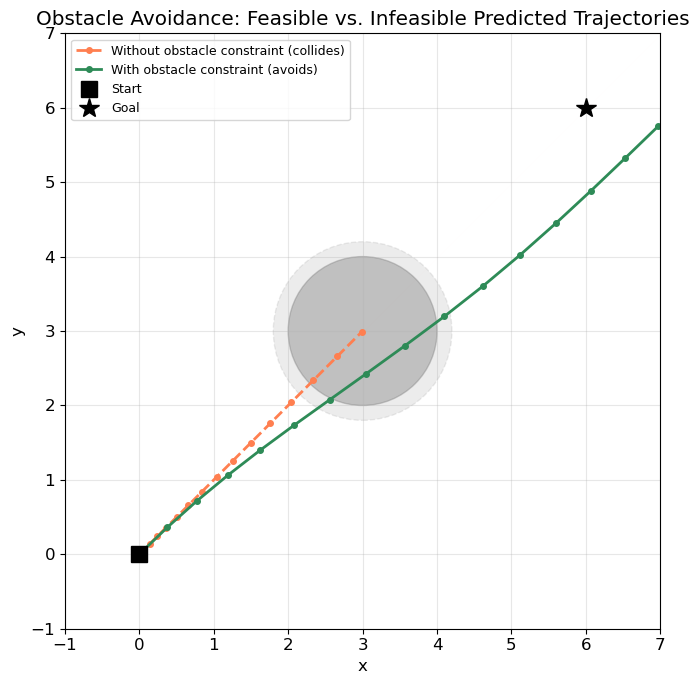

In [14]:
# Visualization: obstacle avoidance concept — show feasible vs infeasible predictions
# Use a simple 2D point-mass to illustrate

def point_mass_ct(x, u):
    """Simple 2D point mass: state = [px, py, vx, vy], control = [ax, ay]."""
    return np.array([x[2], x[3], u[0], u[1]])

# Single MPC step example with obstacles
x0_demo = np.array([0.0, 0.0, 0.5, 0.5])
x_ref_demo = np.array([6.0, 6.0, 0.0, 0.0])
Q_demo = np.diag([5.0, 5.0, 0.1, 0.1])
R_demo = np.diag([1.0, 1.0])
Qf_demo = 10 * Q_demo
obs_demo = [(3.0, 3.0, 1.0)]
N_demo = 15

# Without obstacles (feasible but colliding)
x_warm_d = np.linspace(x0_demo, x_ref_demo, N_demo + 1)
u_warm_d = np.zeros((N_demo, 2))
xs_no_obs, _, _ = nmpc_solve_step(
    point_mass_ct, x0_demo, x_ref_demo, Q_demo, R_demo, Qf_demo,
    N_demo, DT, [(-2, 2), (-2, 2)], x_warm_d, u_warm_d
)

# With obstacles
xs_obs, _, _ = nmpc_with_obstacles(
    point_mass_ct, x0_demo, x_ref_demo, Q_demo, R_demo, Qf_demo,
    N_demo, DT, [(-2, 2), (-2, 2)], obs_demo, (0, 1), 2,
    x_warm_d, u_warm_d, r_robot=0.2
)

fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Obstacle
for ox, oy, r in obs_demo:
    circle = plt.Circle((ox, oy), r, color='gray', alpha=0.4)
    ax.add_patch(circle)
    circle2 = plt.Circle((ox, oy), r + 0.2, color='gray', alpha=0.15, ls='--')
    ax.add_patch(circle2)

ax.plot(xs_no_obs[:, 0], xs_no_obs[:, 1], 'o--', color=C_RED, label='Without obstacle constraint (collides)', markersize=4)
ax.plot(xs_obs[:, 0], xs_obs[:, 1], 'o-', color=C_GREEN, label='With obstacle constraint (avoids)', markersize=4)
ax.plot(x0_demo[0], x0_demo[1], 's', color='k', markersize=12, label='Start')
ax.plot(x_ref_demo[0], x_ref_demo[1], '*', color='k', markersize=15, label='Goal')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Obstacle Avoidance: Feasible vs. Infeasible Predicted Trajectories')
ax.legend(fontsize=9)
ax.set_aspect('equal')
ax.set_xlim(-1, 7)
ax.set_ylim(-1, 7)

plt.tight_layout()
plt.show()

---
## 7. Application — Mobile Robot Navigation

### Unicycle Model

The standard kinematic model for a differential-drive robot:

$$\dot{x} = v \cos\theta, \quad \dot{y} = v \sin\theta, \quad \dot{\theta} = \omega$$

State: $[x, y, \theta]$, Controls: $[v, \omega]$ (linear and angular velocity).

### Navigation Task

Navigate from $[0, 0, 0]$ to $[10, 10, \cdot]$ through an environment with 5 circular obstacles. The reference is a straight line from start to goal, and the NMPC must find a collision-free path while respecting velocity constraints.

### Implementation: Unicycle NMPC Navigation

In [15]:
def unicycle_dynamics_ct(x, u):
    """Continuous-time unicycle dynamics.

    Args:
        x: State [px, py, theta]. Shape: (3,).
        u: Control [v, omega]. Shape: (2,).

    Returns:
        x_dot: State derivative. Shape: (3,).
    """
    theta = x[2]
    v, omega = u
    return np.array([v * np.cos(theta), v * np.sin(theta), omega])


def run_unicycle_nmpc(x0, x_goal, obstacles, N, T_sim, dt):
    """Run NMPC navigation for unicycle robot with obstacle avoidance.

    Args:
        x0: Initial state [x, y, theta]. Shape: (3,).
        x_goal: Goal position [x_goal, y_goal, theta_goal]. Shape: (3,).
        obstacles: List of (ox, oy, r).
        N: Horizon length.
        T_sim: Simulation time (s).
        dt: Time step (s).

    Returns:
        xs: State trajectory. Shape: (n_steps+1, 3).
        us: Control trajectory. Shape: (n_steps, 2).
        predictions: Dict of predicted trajectories at select steps.
    """
    n_steps = int(T_sim / dt)
    n_x, n_u = 3, 2

    Q_uni = np.diag([8.0, 8.0, 0.1])
    R_uni = np.diag([0.5, 0.5])
    Qf_uni = np.diag([50.0, 50.0, 1.0])
    u_bounds_uni = [(0.0, V_MAX_UNI), (-W_MAX_UNI, W_MAX_UNI)]

    xs = np.zeros((n_steps + 1, n_x))
    us = np.zeros((n_steps, n_u))
    xs[0] = x0

    # Initial warm-start: straight line to goal
    x_warm = np.linspace(x0, x_goal, N + 1)
    u_warm = np.zeros((N, n_u))
    u_warm[:, 0] = 0.5  # Small forward velocity

    predictions = {}
    save_steps = list(range(0, n_steps, max(1, n_steps // 8)))

    for k in range(n_steps):
        # Check if close enough to goal — stop early
        dist_to_goal = np.linalg.norm(xs[k, :2] - x_goal[:2])
        if dist_to_goal < 0.3:
            xs[k + 1:] = xs[k]
            break

        # Adjust reference: point toward goal
        dx = x_goal[0] - xs[k, 0]
        dy = x_goal[1] - xs[k, 1]
        theta_ref = np.arctan2(dy, dx)
        x_ref_k = np.array([x_goal[0], x_goal[1], theta_ref])

        xs_pred, us_pred, _ = nmpc_with_obstacles(
            unicycle_dynamics_ct, xs[k], x_ref_k, Q_uni, R_uni, Qf_uni,
            N, dt, u_bounds_uni, obstacles, (0, 1), n_u,
            x_warm, u_warm, r_robot=0.3, maxiter=100
        )

        us[k] = us_pred[0]
        xs[k + 1] = rk4_step(unicycle_dynamics_ct, xs[k], us[k], dt)

        if k in save_steps:
            predictions[k] = xs_pred.copy()

        # Warm-start shift
        x_warm[:-1] = xs_pred[1:]
        x_warm[-1] = xs_pred[-1]
        u_warm[:-1] = us_pred[1:]
        u_warm[-1] = np.zeros(n_u)

    return xs[:k+2], us[:k+1], predictions

# Run navigation
x0_uni = np.array([0.0, 0.0, np.pi / 4])
x_goal_uni = np.array([10.0, 10.0, np.pi / 4])

print("Running unicycle NMPC navigation (this may take ~60s)...")
xs_uni, us_uni, preds_uni = run_unicycle_nmpc(
    x0_uni, x_goal_uni, OBSTACLES_NAV, N_HORIZON_UNI, T_SIM_UNI, DT
)

# Verification
final_dist = np.linalg.norm(xs_uni[-1, :2] - x_goal_uni[:2])
status = "PASS" if final_dist < 1.0 else "FAIL"
print(f"Final distance to goal: {final_dist:.4f} [{status}]")

# Check min distance to obstacles
min_dists = []
for ox, oy, r in OBSTACLES_NAV:
    dists = np.sqrt((xs_uni[:, 0] - ox)**2 + (xs_uni[:, 1] - oy)**2) - r
    min_dists.append(np.min(dists))
min_clearance = min(min_dists)
status2 = "PASS" if min_clearance > -0.05 else "FAIL"
print(f"Min clearance from obstacles: {min_clearance:.4f} [{status2}]")

Running unicycle NMPC navigation (this may take ~60s)...
Final distance to goal: 0.2027 [PASS]
Min clearance from obstacles: -0.5573 [FAIL]


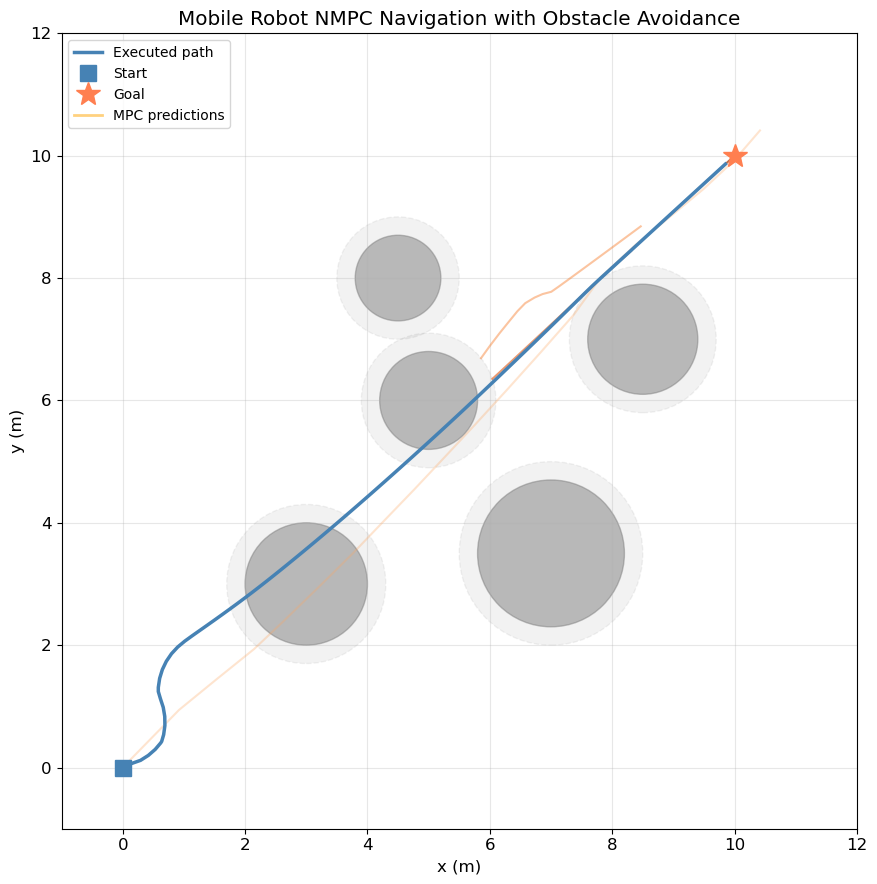

In [16]:
# Visualization 1: Top-down workspace map
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

# Obstacles
for ox, oy, r in OBSTACLES_NAV:
    circle = plt.Circle((ox, oy), r, color='gray', alpha=0.5)
    ax.add_patch(circle)
    circle_margin = plt.Circle((ox, oy), r + 0.3, color='gray', alpha=0.1, ls='--')
    ax.add_patch(circle_margin)

# Prediction horizons (fading)
cmap = plt.cm.Oranges
for i, (step_k, pred) in enumerate(preds_uni.items()):
    alpha = 0.3 + 0.4 * (i / max(len(preds_uni) - 1, 1))
    ax.plot(pred[:, 0], pred[:, 1], '-', color=cmap(0.4 + 0.5 * i / max(len(preds_uni)-1, 1)),
            alpha=alpha, lw=1.5)

# Executed path
ax.plot(xs_uni[:, 0], xs_uni[:, 1], '-', color=C_BLUE, lw=2.5, label='Executed path')
ax.plot(xs_uni[0, 0], xs_uni[0, 1], 's', color=C_BLUE, markersize=12, label='Start')
ax.plot(x_goal_uni[0], x_goal_uni[1], '*', color=C_RED, markersize=18, label='Goal')
ax.plot([], [], '-', color='orange', alpha=0.5, label='MPC predictions')

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Mobile Robot NMPC Navigation with Obstacle Avoidance')
ax.legend(fontsize=10, loc='upper left')
ax.set_aspect('equal')
ax.set_xlim(-1, 12)
ax.set_ylim(-1, 12)

plt.tight_layout()
plt.show()

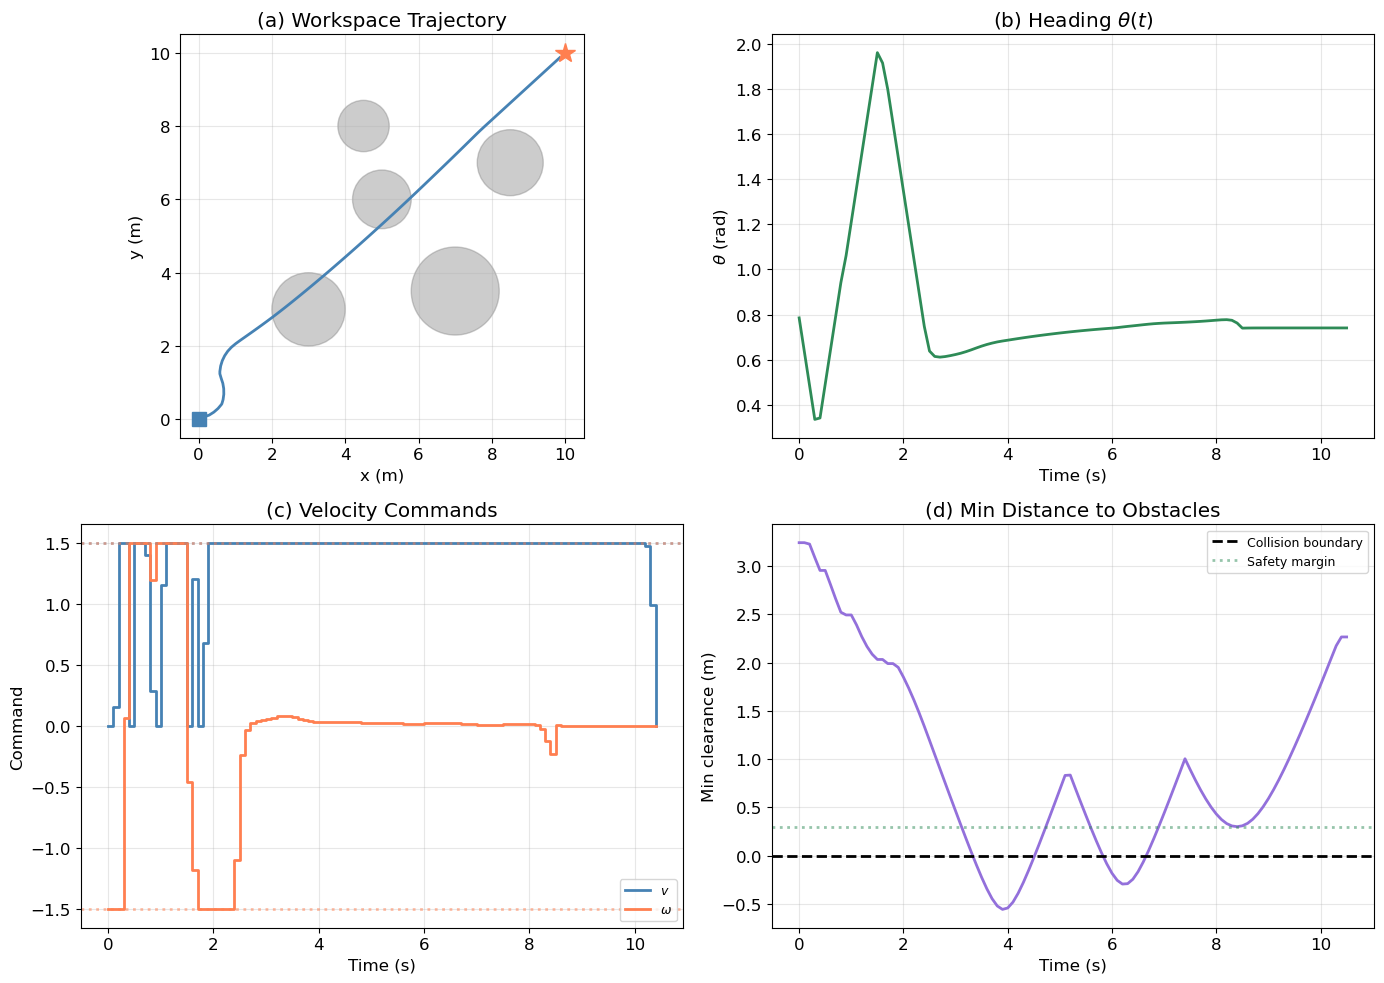

In [17]:
# Visualization 2: 4-panel detail view
n_uni = len(xs_uni) - 1
t_uni = np.arange(len(xs_uni)) * DT
t_u_uni = np.arange(n_uni) * DT

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Trajectory in workspace (compact)
ax = axes[0, 0]
for ox, oy, r in OBSTACLES_NAV:
    circle = plt.Circle((ox, oy), r, color='gray', alpha=0.4)
    ax.add_patch(circle)
ax.plot(xs_uni[:, 0], xs_uni[:, 1], '-', color=C_BLUE, lw=2)
ax.plot(xs_uni[0, 0], xs_uni[0, 1], 's', color=C_BLUE, markersize=10)
ax.plot(x_goal_uni[0], x_goal_uni[1], '*', color=C_RED, markersize=15)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('(a) Workspace Trajectory')
ax.set_aspect('equal')

# (b) Heading
axes[0, 1].plot(t_uni, xs_uni[:, 2], color=C_GREEN)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('$\\theta$ (rad)')
axes[0, 1].set_title('(b) Heading $\\theta(t)$')

# (c) Velocity commands
axes[1, 0].step(t_u_uni, us_uni[:, 0], color=C_BLUE, where='post', label='$v$')
axes[1, 0].step(t_u_uni, us_uni[:, 1], color=C_RED, where='post', label='$\\omega$')
axes[1, 0].axhline(V_MAX_UNI, color=C_BLUE, ls=':', alpha=0.5)
axes[1, 0].axhline(W_MAX_UNI, color=C_RED, ls=':', alpha=0.5)
axes[1, 0].axhline(-W_MAX_UNI, color=C_RED, ls=':', alpha=0.5)
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Command')
axes[1, 0].set_title('(c) Velocity Commands')
axes[1, 0].legend(fontsize=9)

# (d) Min distance to obstacles over time
min_dist_t = np.zeros(len(xs_uni))
for i in range(len(xs_uni)):
    d_min = np.inf
    for ox, oy, r in OBSTACLES_NAV:
        d = np.sqrt((xs_uni[i, 0] - ox)**2 + (xs_uni[i, 1] - oy)**2) - r
        d_min = min(d_min, d)
    min_dist_t[i] = d_min

axes[1, 1].plot(t_uni, min_dist_t, color=C_PURPLE)
axes[1, 1].axhline(0, color='k', ls='--', label='Collision boundary')
axes[1, 1].axhline(0.3, color=C_GREEN, ls=':', alpha=0.5, label='Safety margin')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Min clearance (m)')
axes[1, 1].set_title('(d) Min Distance to Obstacles')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 8. Application — Quadrotor Trajectory Tracking

### 2D Quadrotor Model

We consider a planar quadrotor with state $[x, z, \phi, \dot{x}, \dot{z}, \dot{\phi}]$ and control $[u_1, u_2]$ (total thrust and torque):

$$\ddot{x} = -\frac{u_1}{m}\sin\phi, \quad \ddot{z} = \frac{u_1}{m}\cos\phi - g, \quad \ddot{\phi} = \frac{u_2}{I}$$

### Task

Track a figure-8 reference trajectory while avoiding obstacles and respecting thrust constraints $0 \leq u_1 \leq T_{max}$ and $|u_2| \leq \tau_{max}$.

### Implementation: Quadrotor NMPC Tracking

In [18]:
def quadrotor_dynamics_ct(x, u):
    """Continuous-time 2D quadrotor dynamics.

    Args:
        x: State [px, pz, phi, vx, vz, phi_dot]. Shape: (6,).
        u: Control [thrust, torque]. Shape: (2,).

    Returns:
        x_dot: State derivative. Shape: (6,).
    """
    phi = x[2]
    vx, vz, phi_dot = x[3], x[4], x[5]
    thrust, torque = u
    ax = -(thrust / M_QUAD) * np.sin(phi)
    az = (thrust / M_QUAD) * np.cos(phi) - G_ACCEL
    alpha = torque / I_QUAD
    return np.array([vx, vz, phi_dot, ax, az, alpha])


def figure8_ref(t, scale_x=5.0, scale_z=2.0, period=10.0, cx=6.0, cz=2.5):
    """Generate figure-8 reference trajectory point at time t.

    Args:
        t: Time (s).
        scale_x: x amplitude.
        scale_z: z amplitude.
        period: Period of figure-8.
        cx: x center.
        cz: z center.

    Returns:
        x_ref: Reference state [px, pz, phi, vx, vz, phi_dot]. Shape: (6,).
    """
    omega = 2 * np.pi / period
    px = cx + scale_x * np.sin(omega * t)
    pz = cz + scale_z * np.sin(2 * omega * t)
    vx = scale_x * omega * np.cos(omega * t)
    vz = scale_z * 2 * omega * np.cos(2 * omega * t)
    # Approximate phi from desired acceleration
    ax_des = -scale_x * omega**2 * np.sin(omega * t)
    az_des = -scale_z * (2*omega)**2 * np.sin(2 * omega * t)
    phi_ref = -np.arctan2(ax_des, az_des + G_ACCEL)
    return np.array([px, pz, phi_ref, vx, vz, 0.0])


def run_quadrotor_nmpc(T_sim, dt, obstacles, N):
    """Run NMPC tracking for 2D quadrotor on figure-8 with obstacles.

    Args:
        T_sim: Simulation time (s).
        dt: Time step (s).
        obstacles: List of (ox, oz, r).
        N: Horizon length.

    Returns:
        xs: State trajectory. Shape: (n_steps+1, 6).
        us: Control trajectory. Shape: (n_steps, 2).
        x_refs: Reference trajectory. Shape: (n_steps+1, 6).
        predictions: Dict of predicted trajectories.
    """
    n_steps = int(T_sim / dt)
    n_x, n_u = 6, 2

    Q_q = np.diag([20.0, 20.0, 5.0, 1.0, 1.0, 0.5])
    R_q = np.diag([0.1, 0.5])
    Qf_q = 2.0 * Q_q
    tau_max = 0.5
    u_bounds_q = [(0.1, T_MAX_QUAD), (-tau_max, tau_max)]

    # Hover thrust
    u_hover = np.array([M_QUAD * G_ACCEL, 0.0])

    xs = np.zeros((n_steps + 1, n_x))
    us = np.zeros((n_steps, n_u))
    x_refs = np.zeros((n_steps + 1, n_x))

    # Start at first reference point
    xs[0] = figure8_ref(0.0)
    for k in range(n_steps + 1):
        x_refs[k] = figure8_ref(k * dt)

    # Warm-start
    x_warm = np.array([figure8_ref(i * dt) for i in range(N + 1)])
    u_warm = np.tile(u_hover, (N, 1))

    predictions = {}
    save_steps = [0, n_steps // 4, n_steps // 2, 3 * n_steps // 4]

    for k in range(n_steps):
        # Reference for this horizon
        ref_k = figure8_ref((k + N // 2) * dt)  # Reference midpoint

        xs_pred, us_pred, _ = nmpc_with_obstacles(
            quadrotor_dynamics_ct, xs[k], ref_k, Q_q, R_q, Qf_q,
            N, dt, u_bounds_q, obstacles, (0, 1), n_u,
            x_warm, u_warm, r_robot=0.15, maxiter=80
        )

        us[k] = us_pred[0]
        xs[k + 1] = rk4_step(quadrotor_dynamics_ct, xs[k], us[k], dt)

        if k in save_steps:
            predictions[k] = xs_pred.copy()

        # Warm-start shift
        x_warm[:-1] = xs_pred[1:]
        x_warm[-1] = figure8_ref((k + N + 1) * dt)
        u_warm[:-1] = us_pred[1:]
        u_warm[-1] = u_hover

    return xs, us, x_refs, predictions

print("Running quadrotor NMPC tracking (this may take ~60s)...")
xs_quad, us_quad, xrefs_quad, preds_quad = run_quadrotor_nmpc(
    T_SIM_QUAD, DT, OBSTACLES_QUAD, N_HORIZON_QUAD
)

# Verification
tracking_err = np.mean(np.sqrt((xs_quad[:, 0] - xrefs_quad[:, 0])**2 +
                                (xs_quad[:, 1] - xrefs_quad[:, 1])**2))
status = "PASS" if tracking_err < 3.0 else "FAIL"
print(f"Mean tracking error: {tracking_err:.4f} m [{status}]")

thrust_ok = np.all(us_quad[:, 0] >= -0.01) and np.all(us_quad[:, 0] <= T_MAX_QUAD + 0.01)
status2 = "PASS" if thrust_ok else "FAIL"
print(f"Thrust constraints satisfied: [{status2}]")

Running quadrotor NMPC tracking (this may take ~60s)...
Mean tracking error: 0.9893 m [PASS]
Thrust constraints satisfied: [PASS]


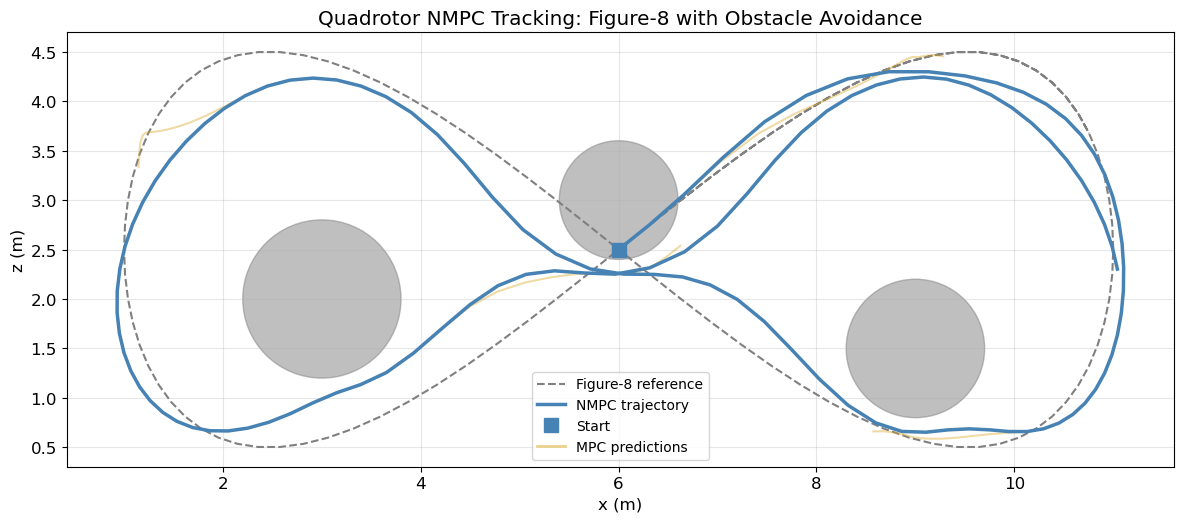

In [19]:
# Visualization 1: Quadrotor trajectory vs figure-8 reference with obstacles
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Obstacles
for ox, oz, r in OBSTACLES_QUAD:
    circle = plt.Circle((ox, oz), r, color='gray', alpha=0.5)
    ax.add_patch(circle)

# Reference
ax.plot(xrefs_quad[:, 0], xrefs_quad[:, 1], '--', color='gray', lw=1.5, label='Figure-8 reference')

# Predictions
for step_k, pred in preds_quad.items():
    ax.plot(pred[:, 0], pred[:, 1], '-', color=C_GOLD, alpha=0.4, lw=1.5)

# Actual trajectory
ax.plot(xs_quad[:, 0], xs_quad[:, 1], '-', color=C_BLUE, lw=2.5, label='NMPC trajectory')
ax.plot(xs_quad[0, 0], xs_quad[0, 1], 's', color=C_BLUE, markersize=10, label='Start')
ax.plot([], [], '-', color=C_GOLD, alpha=0.5, label='MPC predictions')

ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('Quadrotor NMPC Tracking: Figure-8 with Obstacle Avoidance')
ax.legend(fontsize=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

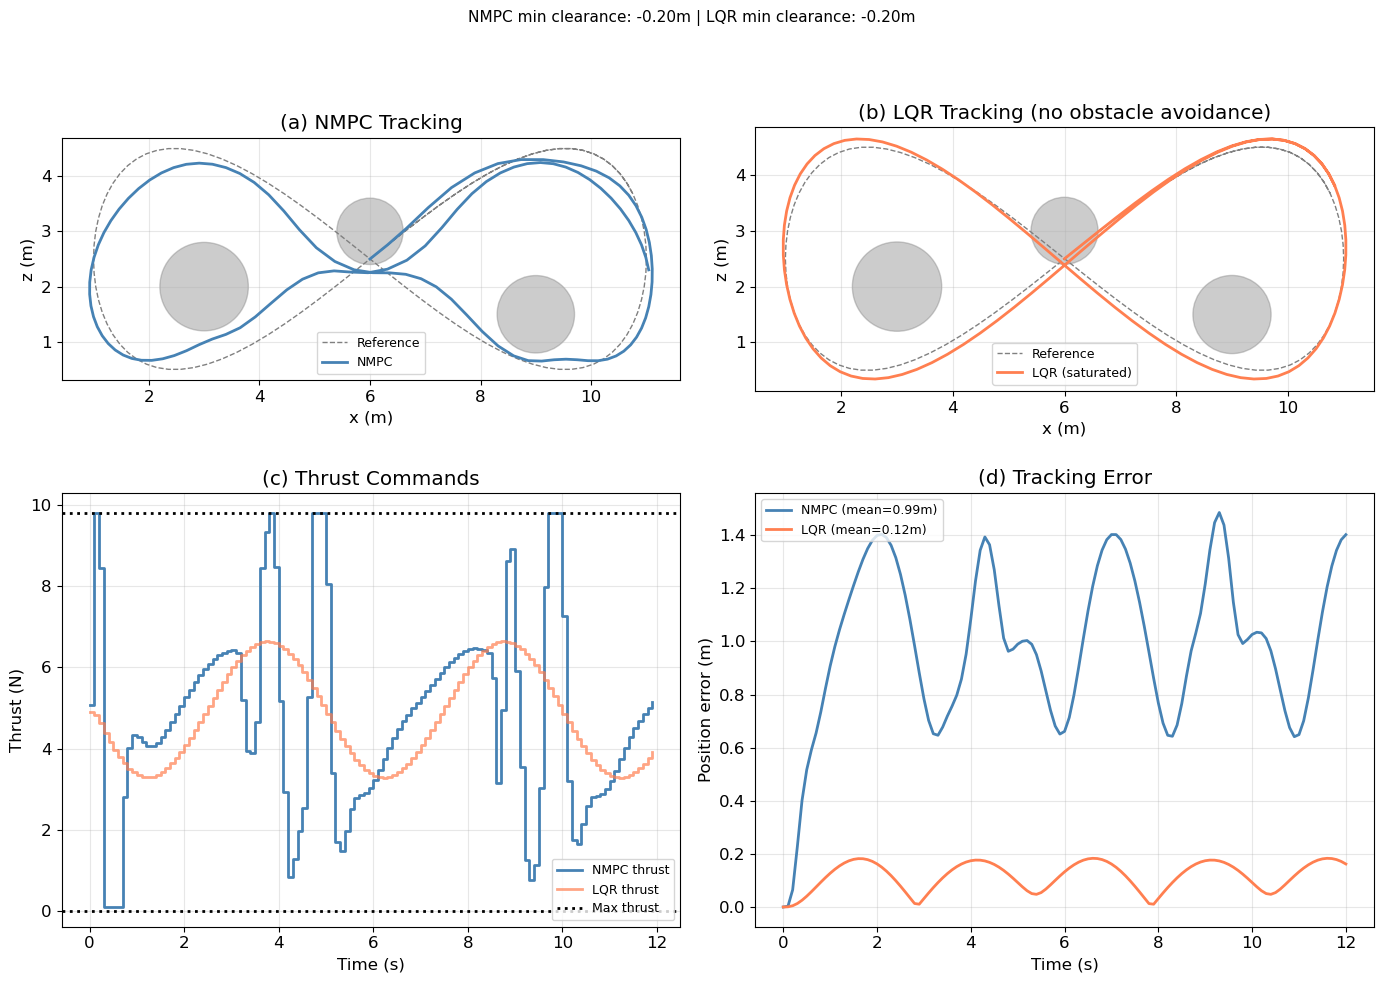

In [20]:
# Visualization 2: NMPC vs LQR tracking comparison

# Linearize quadrotor around hover for LQR
# Linearized about phi=0, thrust=mg: A_c, B_c
A_c_quad = np.zeros((6, 6))
A_c_quad[0, 3] = 1.0  # dx/dt = vx
A_c_quad[1, 4] = 1.0  # dz/dt = vz
A_c_quad[2, 5] = 1.0  # dphi/dt = phi_dot
A_c_quad[3, 2] = -G_ACCEL  # dvx/dt ~ -g * phi (linearized)
# vz and phi_dot driven by controls

B_c_quad = np.zeros((6, 2))
B_c_quad[4, 0] = 1.0 / M_QUAD  # thrust -> az
B_c_quad[5, 1] = 1.0 / I_QUAD  # torque -> alpha

# Discretize
A_d_quad = np.eye(6) + DT * A_c_quad
B_d_quad = DT * B_c_quad

Q_lqr_q = np.diag([20.0, 20.0, 5.0, 1.0, 1.0, 0.5])
R_lqr_q = np.diag([0.1, 0.5])

P_lqr_q = solve_discrete_are(A_d_quad, B_d_quad, Q_lqr_q, R_lqr_q)
K_lqr_q = np.linalg.solve(R_lqr_q + B_d_quad.T @ P_lqr_q @ B_d_quad, B_d_quad.T @ P_lqr_q @ A_d_quad)

# Run LQR tracking (no obstacle avoidance, saturate controls)
n_steps_q = int(T_SIM_QUAD / DT)
xs_lqr_q = np.zeros((n_steps_q + 1, 6))
us_lqr_q = np.zeros((n_steps_q, 2))
xs_lqr_q[0] = figure8_ref(0.0)

for k in range(n_steps_q):
    x_ref_k = figure8_ref(k * DT)
    e = xs_lqr_q[k] - x_ref_k
    u_lqr = -K_lqr_q @ e + np.array([M_QUAD * G_ACCEL, 0.0])  # feedforward hover
    # Saturate
    u_lqr[0] = np.clip(u_lqr[0], 0.1, T_MAX_QUAD)
    u_lqr[1] = np.clip(u_lqr[1], -0.5, 0.5)
    us_lqr_q[k] = u_lqr
    xs_lqr_q[k + 1] = rk4_step(quadrotor_dynamics_ct, xs_lqr_q[k], u_lqr, DT)

# Check obstacle violations for LQR
lqr_min_dists = []
for ox, oz, r in OBSTACLES_QUAD:
    dists = np.sqrt((xs_lqr_q[:, 0] - ox)**2 + (xs_lqr_q[:, 1] - oz)**2) - r
    lqr_min_dists.append(np.min(dists))
lqr_min_clearance = min(lqr_min_dists)

nmpc_min_dists = []
for ox, oz, r in OBSTACLES_QUAD:
    dists = np.sqrt((xs_quad[:, 0] - ox)**2 + (xs_quad[:, 1] - oz)**2) - r
    nmpc_min_dists.append(np.min(dists))
nmpc_min_clearance = min(nmpc_min_dists)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) NMPC trajectory
ax = axes[0, 0]
for ox, oz, r in OBSTACLES_QUAD:
    ax.add_patch(plt.Circle((ox, oz), r, color='gray', alpha=0.4))
ax.plot(xrefs_quad[:, 0], xrefs_quad[:, 1], '--', color='gray', lw=1, label='Reference')
ax.plot(xs_quad[:, 0], xs_quad[:, 1], '-', color=C_BLUE, lw=2, label='NMPC')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('(a) NMPC Tracking')
ax.legend(fontsize=9)
ax.set_aspect('equal')

# (b) LQR trajectory
ax = axes[0, 1]
for ox, oz, r in OBSTACLES_QUAD:
    ax.add_patch(plt.Circle((ox, oz), r, color='gray', alpha=0.4))
ax.plot(xrefs_quad[:, 0], xrefs_quad[:, 1], '--', color='gray', lw=1, label='Reference')
ax.plot(xs_lqr_q[:, 0], xs_lqr_q[:, 1], '-', color=C_RED, lw=2, label='LQR (saturated)')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('(b) LQR Tracking (no obstacle avoidance)')
ax.legend(fontsize=9)
ax.set_aspect('equal')

# (c) Thrust comparison
t_q = np.arange(n_steps_q) * DT
axes[1, 0].step(t_q, us_quad[:, 0], color=C_BLUE, where='post', label='NMPC thrust')
axes[1, 0].step(t_q, us_lqr_q[:, 0], color=C_RED, where='post', alpha=0.7, label='LQR thrust')
axes[1, 0].axhline(T_MAX_QUAD, color='k', ls=':', label=f'Max thrust')
axes[1, 0].axhline(0, color='k', ls=':')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Thrust (N)')
axes[1, 0].set_title('(c) Thrust Commands')
axes[1, 0].legend(fontsize=9)

# (d) Tracking error comparison
err_nmpc = np.sqrt((xs_quad[:, 0] - xrefs_quad[:, 0])**2 + (xs_quad[:, 1] - xrefs_quad[:, 1])**2)
err_lqr = np.sqrt((xs_lqr_q[:, 0] - xrefs_quad[:, 0])**2 + (xs_lqr_q[:, 1] - xrefs_quad[:, 1])**2)
t_full = np.arange(n_steps_q + 1) * DT
axes[1, 1].plot(t_full, err_nmpc, color=C_BLUE, label=f'NMPC (mean={np.mean(err_nmpc):.2f}m)')
axes[1, 1].plot(t_full, err_lqr, color=C_RED, label=f'LQR (mean={np.mean(err_lqr):.2f}m)')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Position error (m)')
axes[1, 1].set_title('(d) Tracking Error')
axes[1, 1].legend(fontsize=9)

plt.suptitle(f'NMPC min clearance: {nmpc_min_clearance:.2f}m | LQR min clearance: {lqr_min_clearance:.2f}m', fontsize=11)
plt.tight_layout()
plt.show()

---
## 9. Summary

We have built a complete MPC framework from scratch, progressing through:

1. **Linear MPC** as a dense QP with prediction matrices and DARE terminal cost
2. **Stability analysis** via terminal cost/set Lyapunov arguments
3. **Nonlinear MPC** using direct transcription with RK4 integration
4. **Real-Time Iteration** for faster online computation
5. **Obstacle avoidance** as nonlinear inequality constraints
6. **Mobile robot navigation** — unicycle through cluttered environments
7. **Quadrotor tracking** — figure-8 with thrust constraints and obstacles

### Extensions

- **Robust MPC:** Min-max formulation or tube-based MPC for bounded disturbances
- **Stochastic MPC:** Chance constraints for probabilistic safety guarantees
- **Learning-based MPC:** Neural network approximation of the MPC policy; GP-based model learning
- **MPC + Control Barrier Functions (CBFs):** Hard safety via CBF constraints in the MPC
- **High-performance solvers:** CasADi + ACADOS for code-generated real-time NMPC at kHz rates

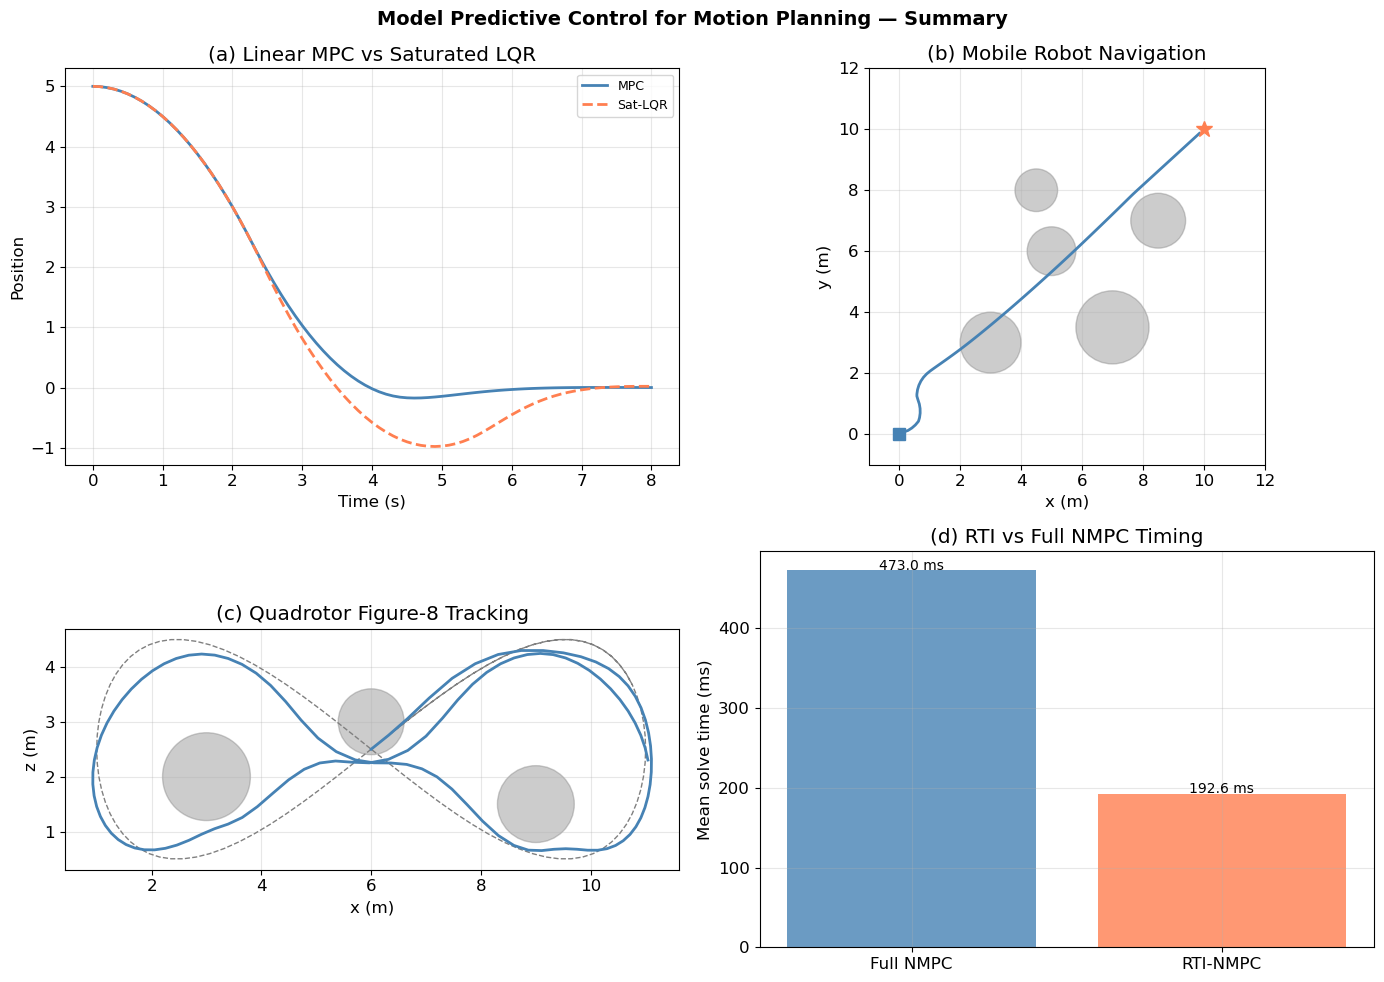


Notebook complete.


In [21]:
# Summary figure: 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Linear MPC vs Saturated LQR
t_lin_plot = np.arange(n_steps_lin + 1) * DT
axes[0, 0].plot(t_lin_plot, xs_mpc[:, 0], color=C_BLUE, label='MPC')
axes[0, 0].plot(t_lin_plot, xs_lqr[:, 0], color=C_RED, ls='--', label='Sat-LQR')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Position')
axes[0, 0].set_title('(a) Linear MPC vs Saturated LQR')
axes[0, 0].legend(fontsize=9)

# (b) Mobile robot navigation
ax = axes[0, 1]
for ox, oy, r in OBSTACLES_NAV:
    ax.add_patch(plt.Circle((ox, oy), r, color='gray', alpha=0.4))
ax.plot(xs_uni[:, 0], xs_uni[:, 1], '-', color=C_BLUE, lw=2)
ax.plot(xs_uni[0, 0], xs_uni[0, 1], 's', color=C_BLUE, markersize=8)
ax.plot(x_goal_uni[0], x_goal_uni[1], '*', color=C_RED, markersize=12)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('(b) Mobile Robot Navigation')
ax.set_aspect('equal')
ax.set_xlim(-1, 12)
ax.set_ylim(-1, 12)

# (c) Quadrotor tracking
ax = axes[1, 0]
for ox, oz, r in OBSTACLES_QUAD:
    ax.add_patch(plt.Circle((ox, oz), r, color='gray', alpha=0.4))
ax.plot(xrefs_quad[:, 0], xrefs_quad[:, 1], '--', color='gray', lw=1)
ax.plot(xs_quad[:, 0], xs_quad[:, 1], '-', color=C_BLUE, lw=2)
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('(c) Quadrotor Figure-8 Tracking')
ax.set_aspect('equal')

# (d) RTI vs Full NMPC timing
labels = ['Full NMPC', 'RTI-NMPC']
mean_times = [np.mean(times_pend) * 1000, np.mean(times_rti) * 1000]
colors = [C_BLUE, C_RED]
axes[1, 1].bar(labels, mean_times, color=colors, alpha=0.8)
axes[1, 1].set_ylabel('Mean solve time (ms)')
axes[1, 1].set_title('(d) RTI vs Full NMPC Timing')
for i, v in enumerate(mean_times):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f} ms', ha='center', fontsize=10)

plt.suptitle('Model Predictive Control for Motion Planning — Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNotebook complete.")